<a href="https://colab.research.google.com/github/io-uty/skt-pytorch/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformers 모델 실습

1. ViT (Vision Transformer) - 이미지 분류 (인코더)
2. BERT - 문장 분류 (인코더)
3. GPT-2 - 텍스트 생성 (디코더)
4. DETR - 객체 검출 (인코더-디코더)

### 0. 설치

In [1]:
!pip install transformers torch torchvision matplotlib pillow

### 1. 라이브러리 임포트, 환경 설정

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

from transformers import (
    ViTImageProcessor, ViTForImageClassification,
    AutoTokenizer, AutoModelForSequenceClassification,
    GPT2Tokenizer, GPT2LMHeadModel,
    DetrImageProcessor, DetrForObjectDetection,
    pipeline
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

### 2.ViT (Vision Transformer)
- ViT는 이미지 분류에 특화된 인코더 모델
- 전 학습된 google/vit-base-patch16-224 모델 사용


#### 순서
- Image Processor 과 모델 로드
- 테스트이미지 준비
- 전처리 후 추론
- Top-5 결과 출력 및 바 차트 시각화
- 원본이미지, Top1 결과 시각화

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Egyptian cat              | 점수: 0.9375
tabby, tabby cat          | 점수: 0.0384
tiger cat                 | 점수: 0.0144
lynx, catamount           | 점수: 0.0033
Siamese cat, Siamese      | 점수: 0.0007


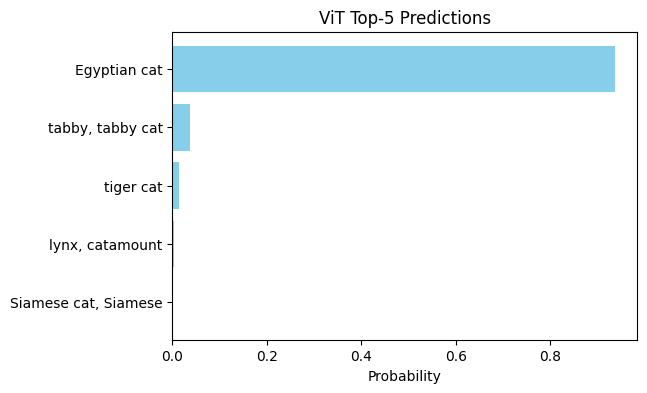

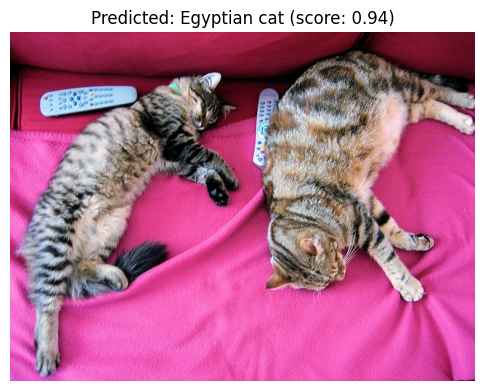

In [6]:
model_name_vit = "google/vit-base-patch16-224"
processor_vit = ViTImageProcessor.from_pretrained(model_name_vit)
model_vit = ViTForImageClassification.from_pretrained(model_name_vit)

# 변경된 URL: 안정적인 다른 이미지로 교체합니다.
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor_vit(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model_vit(**inputs)

logits = outputs.logits

pred_prob = torch.nn.functional.softmax(logits, dim=1)
top5 = torch.topk(pred_prob, k=5)
# 4) 결과 확인 (Top-5)
labels_top5 = [model_vit.config.id2label[idx.item()] for idx in top5.indices[0]]
scores_top5 = [score.item() for score in top5.values[0]]
for label, score in zip(labels_top5, scores_top5):
  print(f"{label:25s} | 점수: {score:.4f}")

plt.figure(figsize=(6, 4))
plt.barh(labels_top5, scores_top5, color='skyblue')
plt.gca().invert_yaxis() # 위에서 아래로 높은 점수가 오도록
plt.xlabel("Probability")
plt.title("ViT Top-5 Predictions")
plt.show()

top1_label = labels_top5[0]
top1_score = scores_top5[0]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Predicted: {top1_label} (score: {top1_score:.2f})")
plt.axis('off')
plt.show()

### 3. BERT (Sentiment Analysis)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

=== 감정 분석 결과 (별 1~5) ===

문장: 이 제품은 정말 최고야! 너무 마음에 들어.
결과: {'label': '5 stars', 'score': 0.9130706191062927}

문장: 솔직히 별로야. 돈이 아까움.
결과: {'label': '1 star', 'score': 0.42365762591362}

문장: Just okay, not too good, not too bad.
결과: {'label': '3 stars', 'score': 0.867607831954956}

문장: I absolutely love this! It's fantastic.
결과: {'label': '5 stars', 'score': 0.9735479354858398}

문장: Terrible experience. I hate it.
결과: {'label': '1 star', 'score': 0.8979193568229675}



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


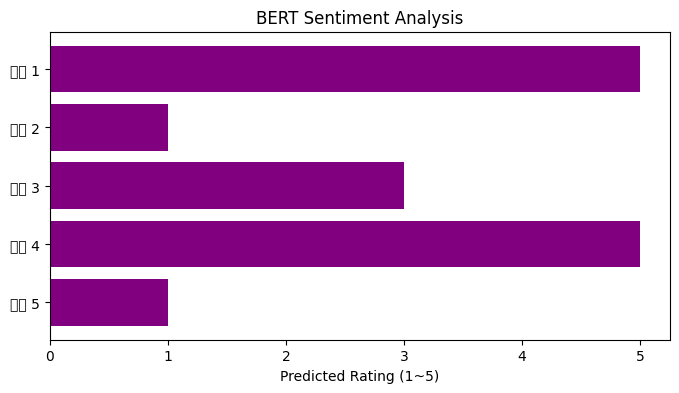

In [7]:
model_name_bert = "nlptown/bert-base-multilingual-uncased-sentiment"
classifier_bert = pipeline("sentiment-analysis", model=model_name_bert, tokenizer=model_name_bert, device=0 if torch.cuda.is_available() else -1)
sentences = [
"이 제품은 정말 최고야! 너무 마음에 들어.",
"솔직히 별로야. 돈이 아까움.",
"Just okay, not too good, not too bad.",
"I absolutely love this! It's fantastic.",
"Terrible experience. I hate it."
]
results = classifier_bert(sentences)
print("=== 감정 분석 결과 (별 1~5) ===\n")
for sentence, result in zip(sentences, results):
  print(f"문장: {sentence}")
  print(f"결과: {result}\n")

numeric_labels = [int(res['label'].split()[0]) for res in results] # '5 stars' -> 5
plt.figure(figsize=(8, 4))
plt.barh(range(len(sentences)), numeric_labels, color='purple')
plt.yticks(range(len(sentences)), [f"문장 {i+1}" for i in range(len(sentences))])
plt.xlabel('Predicted Rating (1~5)')
plt.title('BERT Sentiment Analysis')
plt.gca().invert_yaxis()
plt.show()

### 4. GPT-2 (Text Generation)
- GPT-2는 디코더 기반 언어 모델로, 텍스트 생성에 특화되어있음


#### 구성 순서
- GPT-2 모델 및 토크나이저 로드
- 프롬프트 정의
- 파이프라인으로 텍스트 생성
- 여러 개 샘플 확인

In [8]:
model_name_gpt2 = "gpt2"
gpt2_generator = pipeline(
"text-generation",
model=model_name_gpt2,
tokenizer=model_name_gpt2,
device=0 if torch.cuda.is_available() else -1
)
prompt = "Once upon a time," # 영어 예제
generated_texts = gpt2_generator(
prompt,
max_length=50,
num_return_sequences=3,
do_sample=True,
top_k=50,
top_p=0.95
)
for i, gen in enumerate(generated_texts):
  print(f"[생성 {i+1}] {gen['generated_text']}")
  print("-" * 80)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences', 'top_p', 'top_k', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization

[생성 1] Once upon a time, the Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's life and death were inextricably bound together.

The Emperor's l

### 5. DETR (Detection Transformer)
- 인코더-디코더 구조를 가진 객체 검출 모델로, 이미지 내 객체 위치(바운딩 박스)와 클래스를 추론

### 구성 순서
- facebook/detr-resnet-50 모델과 Image Processor 로드
- 테스트 이미지 로드
- 모델 추론
- 바운딩 박스, 클래스, 스코어 추출 후 필터링
- 시각화 (박스 + 라벨 + 점수)

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


검출된 객체 수(임계값 0.7 이상): 24


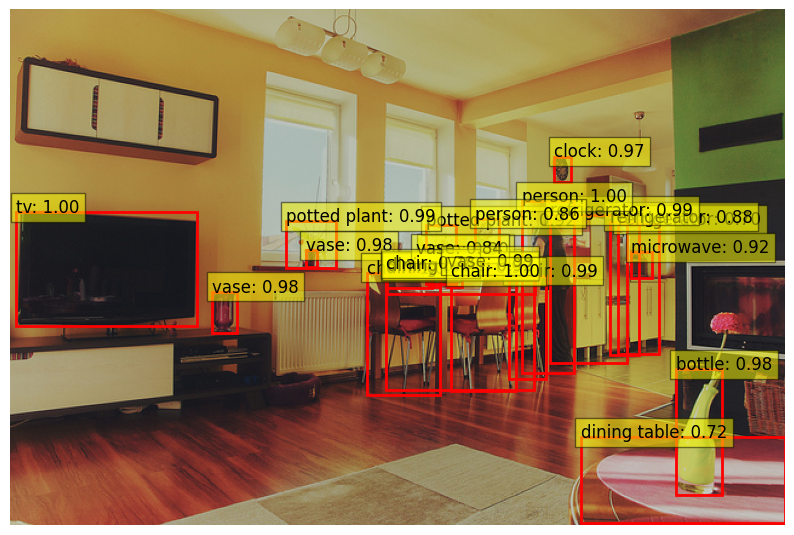

In [15]:
import io

model_name_detr = "facebook/detr-resnet-50"
processor_detr = DetrImageProcessor.from_pretrained(model_name_detr)
model_detr = DetrForObjectDetection.from_pretrained(model_name_detr).to(device)
# URL을 수정하여 "SyntaxError: unterminated string literal"를 해결하고, 더 안정적인 이미지로 교체합니다.
# UnidentifiedImageError 해결을 위해 새로운 안정적인 이미지 URL로 변경하고, 요청 상태를 확인합니다.
url_detr = "http://images.cocodataset.org/val2017/000000000139.jpg"

# io.BytesIO를 사용하여 이미지를 더 안정적으로 로드합니다.
response = requests.get(url_detr)
response.raise_for_status() # HTTP 요청이 성공했는지 확인
image_detr = Image.open(io.BytesIO(response.content))

inputs_detr = processor_detr(images=image_detr, return_tensors="pt").to(device)
with torch.no_grad():
    outputs_detr = model_detr(**inputs_detr)
logits = outputs_detr.logits[0] # (num_queries, num_classes)
pred_boxes = outputs_detr.pred_boxes[0] # (num_queries, 4) -> center_x, center_y, w, h
probs = logits.softmax(-1)
probs_no_object = probs[..., :-1]
max_probs, class_ids = probs_no_object.max(dim=-1)
threshold = 0.7
keep = max_probs > threshold
boxes_to_plot = pred_boxes[keep]
scores_to_plot = max_probs[keep] # 'schores_to_plot' 오타 수정
class_ids_to_plot = class_ids[keep]
print(f"검출된 객체 수(임계값 {threshold} 이상): {len(boxes_to_plot)}")
# 5) 시각화 (matplotlib)
plt.figure(figsize=(10, 10))
plt.imshow(image_detr)
ax = plt.gca()
img_w, img_h = image_detr.size
import matplotlib.patches as patches
for box, score, class_id in zip(boxes_to_plot, scores_to_plot, class_ids_to_plot):
    cx, cy, w, h = box
    # center_x, center_y, width, height -> x1, y1로 변환
    cx, cy, w, h = cx*img_w, cy*img_h, w*img_w, h*img_h
    x1 = cx - 0.5*w
    y1 = cy - 0.5*h
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    class_name = model_detr.config.id2label[class_id.item()]
    text = f"{class_name}: {score.item():.2f}"
    ax.text(x1, y1, text, fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))
plt.axis('off')
plt.show()

## 정리
- ViT : 이미지 분류 (인코더)
- BERT : 문장 분류 (인코더)
- GPT-2 : 텍스트 생성 (디코더)
- DETR : 객체 검출 (인코더-디코더)